# Tahap 03 — BERTopic Topic Modeling

**Judul project:** Analisis Topik Pidato Presiden Prabowo pada Sidang Umum Perserikatan Bangsa-Bangsa Menggunakan Manual Analysis dan BERTopic  
**Repository:** `topic-modeling-prabowo-un-speech`  

Notebook ini melakukan pemodelan topik berbasis **BERTopic** pada dataset chunk pidato yang sudah dibuat pada Tahap 01, serta menggunakan hasil **manual analysis** Tahap 02 sebagai referensi pembanding awal.

## 1. Tujuan Notebook

Notebook ini mencakup:

1. import library dan validasi environment,
2. load `data/processed/pidato_prabowo_pbb80_chunks.csv`,
3. load `data/processed/manual_analysis_results.csv` sebagai pembanding awal,
4. validasi kolom teks, missing value, duplikasi, panjang teks, dan jumlah kata,
5. konfigurasi embedding multilingual, CountVectorizer, UMAP, HDBSCAN, dan c-TF-IDF,
6. training BERTopic,
7. ekstraksi topic info, kata kunci, dan representative documents,
8. pemberian label akademik pada setiap topik,
9. export hasil ke CSV,
10. simpan visualisasi ke `reports/figures/`,
11. simpan model ke `models/bertopic_model/`,
12. catatan interpretasi, keterbatasan, troubleshooting, dan perintah Git commit.

## 2. Konsep Akademik BERTopic

**BERTopic** adalah teknik *topic modeling* modern yang mengombinasikan transformer-based embedding dan c-TF-IDF untuk membentuk topik yang lebih mudah diinterpretasikan. Alurnya dapat dipahami sebagai berikut:

1. **Sentence Embedding**: teks diubah menjadi vektor semantik menggunakan model transformer.
2. **UMAP**: embedding berdimensi tinggi direduksi ke dimensi yang lebih rendah agar struktur semantik lokal lebih mudah dikelompokkan.
3. **HDBSCAN**: dokumen dikelompokkan berdasarkan kepadatan. Dokumen yang tidak cukup dekat dengan cluster dapat diberi label `-1` sebagai outlier.
4. **c-TF-IDF**: kata/frasa paling representatif diekstraksi untuk menjelaskan setiap cluster sebagai topik.

Pada project ini, BERTopic tidak menggantikan manual analysis, melainkan menjadi metode komputasional untuk melakukan triangulasi terhadap hasil open coding, axial coding, dan selective coding.

## 3. Catatan Parameter untuk Dataset Kecil

Dataset berasal dari **satu pidato** yang dipecah menjadi beberapa chunk. Karena itu, parameter dibuat konservatif:

- `UMAP n_neighbors` dibuat kecil agar struktur lokal antar chunk tetap terlihat.
- `HDBSCAN min_cluster_size` dibuat kecil agar cluster tetap bisa terbentuk.
- `HDBSCAN min_samples=1` digunakan untuk mengurangi dominasi topic `-1`.
- Stopwords diterapkan pada `CountVectorizer`, bukan pada teks sebelum embedding, agar embedding tetap mempertahankan konteks kalimat.

## 4. Import Library dan Validasi Environment

In [1]:
# ============================================================
# Import library dasar
# ============================================================

import sys
import os
import re
import json
import warnings
import importlib
import importlib.metadata as importlib_metadata
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

print("Python version:", sys.version)
print("Current working directory:", Path.cwd())

Python version: 3.10.20 | packaged by Anaconda, Inc. | (main, Mar 11 2026, 17:42:35) [MSC v.1942 64 bit (AMD64)]
Current working directory: D:\DATA-KAMIL\MATKUL\SEMESTER-1\DATA-MINING\topic-modeling-prabowo-un-speech\notebooks


In [2]:
# ============================================================
# Validasi versi package utama
# ============================================================

packages = {
    "pandas": "pandas",
    "numpy": "numpy",
    "matplotlib": "matplotlib",
    "sklearn": "scikit-learn",
    "sentence_transformers": "sentence-transformers",
    "bertopic": "bertopic",
    "umap": "umap-learn",
    "hdbscan": "hdbscan",
    "plotly": "plotly",
}

version_rows = []
missing_packages = []

for import_name, package_name in packages.items():
    try:
        importlib.import_module(import_name)
        version = importlib_metadata.version(package_name)
        status = "OK"
    except Exception as e:
        version = None
        status = f"MISSING / ERROR: {type(e).__name__}"
        missing_packages.append(package_name)
    version_rows.append({
        "import_name": import_name,
        "package_name": package_name,
        "version": version,
        "status": status
    })

version_df = pd.DataFrame(version_rows)
display(version_df)

if missing_packages:
    print("Package yang perlu diinstall:")
    print("pip install " + " ".join(sorted(set(missing_packages))))
else:
    print("Semua package utama tersedia.")

,import_name,package_name,version,status
0,pandas,pandas,2.3.3,OK
1,numpy,numpy,2.2.6,OK
2,matplotlib,matplotlib,3.10.9,OK
3,sklearn,scikit-learn,1.7.2,OK
4,sentence_transformers,sentence-transformers,5.5.1,OK
5,bertopic,bertopic,0.17.4,OK
6,umap,umap-learn,0.5.12,OK
7,hdbscan,hdbscan,0.8.44,OK
8,plotly,plotly,6.8.0,OK


Semua package utama tersedia.


**Output yang diharapkan:** semua package utama berstatus `OK`.  
**Interpretasi:** jika `bertopic`, `sentence-transformers`, `umap-learn`, atau `hdbscan` belum tersedia, jalankan perintah instalasi yang ditampilkan.

In [3]:
# ============================================================
# Import library khusus BERTopic
# ============================================================

from sentence_transformers import SentenceTransformer
from bertopic import BERTopic
from bertopic.vectorizers import ClassTfidfTransformer
from sklearn.feature_extraction.text import CountVectorizer
from umap import UMAP
from hdbscan import HDBSCAN

print("Library BERTopic dan dependency berhasil diimport.")

Library BERTopic dan dependency berhasil diimport.


**Output yang diharapkan:** library BERTopic dan dependency berhasil diimport.  
**Interpretasi:** environment sudah siap untuk topic modeling.

## 5. Setup Path Project

In [4]:
# ============================================================
# Setup path project
# ============================================================

CURRENT_DIR = Path.cwd()
PROJECT_ROOT = CURRENT_DIR.parent if CURRENT_DIR.name.lower() == "notebooks" else CURRENT_DIR

DATA_PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
REPORTS_FIGURES_DIR = PROJECT_ROOT / "reports" / "figures"
MODELS_DIR = PROJECT_ROOT / "models" / "bertopic_model"

DATA_PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
REPORTS_FIGURES_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.parent.mkdir(parents=True, exist_ok=True)

CHUNKS_PATH = DATA_PROCESSED_DIR / "pidato_prabowo_pbb80_chunks.csv"
MANUAL_ANALYSIS_PATH = DATA_PROCESSED_DIR / "manual_analysis_results.csv"

print("PROJECT_ROOT       :", PROJECT_ROOT)
print("CHUNKS_PATH        :", CHUNKS_PATH)
print("MANUAL_ANALYSIS    :", MANUAL_ANALYSIS_PATH)
print("REPORTS_FIGURES_DIR:", REPORTS_FIGURES_DIR)
print("MODELS_DIR         :", MODELS_DIR)

PROJECT_ROOT       : D:\DATA-KAMIL\MATKUL\SEMESTER-1\DATA-MINING\topic-modeling-prabowo-un-speech
CHUNKS_PATH        : D:\DATA-KAMIL\MATKUL\SEMESTER-1\DATA-MINING\topic-modeling-prabowo-un-speech\data\processed\pidato_prabowo_pbb80_chunks.csv
MANUAL_ANALYSIS    : D:\DATA-KAMIL\MATKUL\SEMESTER-1\DATA-MINING\topic-modeling-prabowo-un-speech\data\processed\manual_analysis_results.csv
REPORTS_FIGURES_DIR: D:\DATA-KAMIL\MATKUL\SEMESTER-1\DATA-MINING\topic-modeling-prabowo-un-speech\reports\figures
MODELS_DIR         : D:\DATA-KAMIL\MATKUL\SEMESTER-1\DATA-MINING\topic-modeling-prabowo-un-speech\models\bertopic_model


**Output yang diharapkan:** path project dan file input tampil benar.  
**Interpretasi:** jika path belum sesuai, pastikan notebook dijalankan dari folder `notebooks/` atau root repository.

## 6. Load Dataset Chunk dan Manual Analysis

In [5]:
# ============================================================
# Load dataset hasil chunking
# ============================================================

if not CHUNKS_PATH.exists():
    raise FileNotFoundError(f"File chunk tidak ditemukan: {CHUNKS_PATH}")

df_chunks = pd.read_csv(CHUNKS_PATH)
print("Dataset chunk berhasil dimuat.")
print("Shape df_chunks:", df_chunks.shape)
display(df_chunks.head())

Dataset chunk berhasil dimuat.
Shape df_chunks: (39, 7)


,chunk_id,sentence_start,sentence_end,sentence_count,chunk_text,char_count,word_count
0,1,1,3,3,"His Excellency Mr. Antoni Guterres, Secretary ...",602,86
1,2,4,6,3,We are here first and foremost as fellow human...,527,78
2,3,7,9,3,“All men are created equal” was the creed that...,421,64
3,4,10,12,3,"My country knows this pain. For centuries, Ind...",164,25
4,5,13,15,3,We Indonesians know what it means to be denied...,346,60


**Output yang diharapkan:** dataset chunk berhasil dimuat dan preview tampil.  
**Interpretasi:** setiap baris dataset akan diperlakukan sebagai satu dokumen/chunk untuk BERTopic.

In [6]:
# ============================================================
# Load manual analysis sebagai referensi pembanding
# ============================================================

if MANUAL_ANALYSIS_PATH.exists():
    df_manual = pd.read_csv(MANUAL_ANALYSIS_PATH)
    print("Hasil manual analysis berhasil dimuat.")
    print("Shape df_manual:", df_manual.shape)
    display(df_manual.head())
else:
    df_manual = None
    print("File manual_analysis_results.csv tidak ditemukan. Analisis BERTopic tetap dapat dilanjutkan.")

Hasil manual analysis berhasil dimuat.
Shape df_manual: (39, 13)


,chunk_id,chunk_text,char_count,word_count,primary_open_code,secondary_open_codes,axial_code,selective_code,matched_keywords,coding_score,coding_confidence,evidence_quote,researcher_memo
0,1,"His Excellency Mr. Antoni Guterres, Secretary ...",602,86,Dukungan terhadap PBB,NaN,Penguatan multilateralisme dan peran PBB,Tatanan Dunia yang Adil dan Multilateral,who,1,rendah,"His Excellency Mr. Antoni Guterres, Secretary ...",Perlu ditinjau ulang secara manual karena keco...
1,2,We are here first and foremost as fellow human...,527,80,Diplomasi Indonesia dan Global South,NaN,Diplomasi Indonesia dan Global South,Peran Strategis Indonesia di Forum Global,indonesia,1,rendah,We are here first and foremost as fellow human...,Perlu ditinjau ulang secara manual karena keco...
2,3,“All men are created equal” was the creed that...,421,66,Pengalaman kolonialisme dan ketidakadilan,NaN,Keadilan global dan solidaritas kemanusiaan,Tatanan Dunia yang Adil dan Multilateral,apartheid,1,rendah,“All men are created equal” was the creed that...,Perlu ditinjau ulang secara manual karena keco...
3,4,"My country knows this pain. For centuries, Ind...",164,25,Diplomasi Indonesia dan Global South,NaN,Diplomasi Indonesia dan Global South,Peran Strategis Indonesia di Forum Global,indonesia,1,rendah,"My country knows this pain. For centuries, Ind...",Perlu ditinjau ulang secara manual karena keco...
4,5,We Indonesians know what it means to be denied...,346,60,Diplomasi Indonesia dan Global South,Pengalaman kolonialisme dan ketidakadilan,Diplomasi Indonesia dan Global South,Peran Strategis Indonesia di Forum Global,indonesia,2,sedang,We Indonesians know what it means to be denied...,Kode awal sesuai berdasarkan kemunculan keywor...


**Output yang diharapkan:** hasil manual analysis tampil jika file tersedia.  
**Interpretasi:** hasil manual analysis digunakan sebagai pembanding konseptual, bukan sebagai label target supervised learning.

## 7. Validasi Kolom Teks

In [7]:
# ============================================================
# Deteksi otomatis kolom teks
# ============================================================

candidate_text_columns = [
    "chunk_text", "text", "teks", "clean_text", "text_clean",
    "content", "isi_pidato", "paragraph", "kalimat"
]

available_columns = df_chunks.columns.tolist()
text_col = next((col for col in candidate_text_columns if col in available_columns), None)

if text_col is None:
    string_cols = df_chunks.select_dtypes(include=["object", "string"]).columns.tolist()
    if not string_cols:
        raise ValueError("Tidak ditemukan kolom bertipe teks/string pada dataset chunk.")
    avg_lengths = {col: df_chunks[col].fillna("").astype(str).str.len().mean() for col in string_cols}
    text_col = max(avg_lengths, key=avg_lengths.get)

print("Kolom teks yang digunakan:", text_col)
print("Daftar kolom dataset:", available_columns)

# Jika kolom yang terdeteksi belum sesuai, ubah manual di bawah ini.
# text_col = "chunk_text"

Kolom teks yang digunakan: chunk_text
Daftar kolom dataset: ['chunk_id', 'sentence_start', 'sentence_end', 'sentence_count', 'chunk_text', 'char_count', 'word_count']


**Output yang diharapkan:** nama kolom teks terdeteksi.  
**Interpretasi:** pastikan kolom yang dipilih benar-benar berisi teks chunk pidato.

## 8. Validasi Kualitas Data

In [8]:
# ============================================================
# Validasi jumlah chunk, missing value, duplikasi, panjang teks, dan jumlah kata
# ============================================================

df_work = df_chunks.copy()
df_work[text_col] = df_work[text_col].fillna("").astype(str).str.strip()

candidate_id_columns = ["chunk_id", "id", "document_id", "doc_id", "paragraph_id"]
id_col = next((col for col in candidate_id_columns if col in df_work.columns), None)
if id_col is None:
    id_col = "generated_chunk_id"
    df_work[id_col] = range(1, len(df_work) + 1)

df_work["char_count"] = df_work[text_col].str.len()
df_work["word_count"] = df_work[text_col].apply(lambda x: len(x.split()))
df_work["is_empty_text"] = df_work[text_col].str.len() == 0
df_work["is_duplicate_text"] = df_work.duplicated(subset=[text_col], keep=False)

summary_quality = pd.DataFrame([{
    "jumlah_baris": len(df_work),
    "jumlah_kolom": df_work.shape[1],
    "kolom_id": id_col,
    "kolom_teks": text_col,
    "missing_text": int(df_chunks[text_col].isna().sum()),
    "empty_text": int(df_work["is_empty_text"].sum()),
    "duplicate_text": int(df_work["is_duplicate_text"].sum()),
    "min_char_count": int(df_work["char_count"].min()),
    "max_char_count": int(df_work["char_count"].max()),
    "mean_char_count": round(float(df_work["char_count"].mean()), 2),
    "min_word_count": int(df_work["word_count"].min()),
    "max_word_count": int(df_work["word_count"].max()),
    "mean_word_count": round(float(df_work["word_count"].mean()), 2),
}])

display(summary_quality)
display(df_work[[id_col, text_col, "char_count", "word_count"]].head(10))

,jumlah_baris,jumlah_kolom,kolom_id,kolom_teks,missing_text,empty_text,duplicate_text,min_char_count,max_char_count,mean_char_count,min_word_count,max_word_count,mean_word_count
0,39,9,chunk_id,chunk_text,0,0,0,80,602,283.0,16,89,47.03


,chunk_id,chunk_text,char_count,word_count
0,1,"His Excellency Mr. Antoni Guterres, Secretary ...",602,86
1,2,We are here first and foremost as fellow human...,527,80
2,3,“All men are created equal” was the creed that...,421,66
3,4,"My country knows this pain. For centuries, Ind...",164,25
4,5,We Indonesians know what it means to be denied...,346,60
5,6,Decisions made here based on human solidarity ...,581,85
6,7,"Everyday we witness suffering, genocide, and a...",224,37
7,8,We cannot surrender our hopes or our ideals. W...,148,26
8,9,The United Nations was born from the ashes of ...,302,48
9,10,"Today, Indonesia is nearer than ever before to...",358,59


**Output yang diharapkan:** ringkasan kualitas data dan preview chunk tampil.  
**Interpretasi:** missing text dan empty text idealnya 0. Duplikasi perlu diperiksa karena dapat memperkuat topik tertentu secara tidak proporsional.

,count,mean,std,min,25%,50%,75%,max
char_count,39.0,283.000000,139.939649,80.0,166.0,261.0,359.5,602.0
word_count,39.0,47.025641,21.223729,16.0,28.0,48.0,61.0,89.0


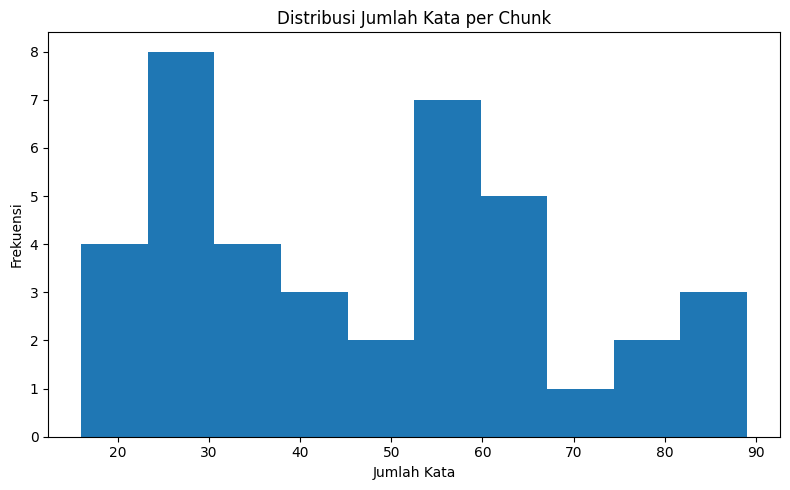

Visualisasi disimpan ke: D:\DATA-KAMIL\MATKUL\SEMESTER-1\DATA-MINING\topic-modeling-prabowo-un-speech\reports\figures\chunk_word_count_distribution.png


In [9]:
# ============================================================
# Visualisasi distribusi jumlah kata per chunk
# ============================================================

length_stats = df_work[["char_count", "word_count"]].describe().T
display(length_stats)

plt.figure(figsize=(8, 5))
plt.hist(df_work["word_count"], bins=10)
plt.title("Distribusi Jumlah Kata per Chunk")
plt.xlabel("Jumlah Kata")
plt.ylabel("Frekuensi")
plt.tight_layout()

word_count_fig_path = REPORTS_FIGURES_DIR / "chunk_word_count_distribution.png"
plt.savefig(word_count_fig_path, dpi=300, bbox_inches="tight")
plt.show()
print("Visualisasi disimpan ke:", word_count_fig_path)

**Output yang diharapkan:** histogram distribusi jumlah kata tampil dan tersimpan.  
**Interpretasi:** chunk yang terlalu pendek dapat membuat topik kurang stabil, sedangkan chunk terlalu panjang dapat mencampur lebih dari satu tema.

## 9. Data Preparation untuk BERTopic

In [10]:
# ============================================================
# Seleksi dokumen valid
# ============================================================

before_rows = len(df_work)
df_model = df_work.copy()
df_model = df_model[~df_model["is_empty_text"]].copy()
df_model = df_model.drop_duplicates(subset=[text_col], keep="first").copy()
df_model = df_model.reset_index(drop=True)

docs = df_model[text_col].tolist()

print("Jumlah baris awal             :", before_rows)
print("Jumlah dokumen valid BERTopic :", len(docs))
print("Jumlah baris dibuang          :", before_rows - len(docs))

if len(docs) < 5:
    raise ValueError("Jumlah dokumen terlalu sedikit untuk BERTopic. Disarankan minimal sekitar 10 chunk agar hasil lebih bermakna.")

Jumlah baris awal             : 39
Jumlah dokumen valid BERTopic : 39
Jumlah baris dibuang          : 0


**Output yang diharapkan:** jumlah dokumen valid tampil.  
**Interpretasi:** BERTopic dapat dijalankan pada dataset kecil, tetapi semakin sedikit chunk maka interpretasi semakin perlu kehati-hatian.

## 10. Stopwords Bahasa Indonesia dan Domain-Specific Stopwords

Stopwords digunakan pada `CountVectorizer`, bukan pada teks sebelum embedding. Dengan demikian, embedding tetap membaca konteks kalimat secara utuh.

In [11]:
# ============================================================
# Stopwords Bahasa Indonesia sederhana + domain-specific stopwords
# ============================================================

stopwords_text = (
    "yang dan di ke dari untuk dengan pada dalam adalah itu ini sebagai atau serta karena maka agar juga telah akan dapat "
    "para kita kami mereka saya anda beliau tidak bukan menjadi sudah lebih sangat antara oleh tentang kepada bagi namun "
    "yaitu yakni hingga ketika dimana pun saja lagi sebuah suatu seorang setiap semua banyak beberapa dalamnya atas bawah "
    "melalui terhadap tanpa seperti demikian tersebut ialah merupakan bila jika kalau sebab sehingga sementara selama sejak "
    "setelah sebelum"
)
stopwords_id = set(stopwords_text.split())

domain_stopwords = set([
    "pidato", "presiden", "prabowo", "subianto",
    "pbb", "perserikatan", "bangsa", "bangsa-bangsa",
    "sidang", "umum", "majelis", "sesi",
    "ke-80", "80", "united", "nations",
    "bapak", "ibu", "hadirin", "terhormat",
])

custom_stopwords = sorted(stopwords_id.union(domain_stopwords))

print("Jumlah stopwords:", len(custom_stopwords))
print(custom_stopwords[:60])

Jumlah stopwords: 97
['80', 'adalah', 'agar', 'akan', 'anda', 'antara', 'atas', 'atau', 'bagi', 'bangsa', 'bangsa-bangsa', 'banyak', 'bapak', 'bawah', 'beberapa', 'beliau', 'bila', 'bukan', 'dalam', 'dalamnya', 'dan', 'dapat', 'dari', 'demikian', 'dengan', 'di', 'dimana', 'hadirin', 'hingga', 'ialah', 'ibu', 'ini', 'itu', 'jika', 'juga', 'kalau', 'kami', 'karena', 'ke', 'ke-80', 'kepada', 'ketika', 'kita', 'lagi', 'lebih', 'majelis', 'maka', 'melalui', 'menjadi', 'mereka', 'merupakan', 'namun', 'nations', 'oleh', 'pada', 'para', 'pbb', 'perserikatan', 'pidato', 'prabowo']


**Output yang diharapkan:** daftar stopwords tampil.  
**Interpretasi:** stopwords dibuat konservatif. Jangan menghapus kata substantif seperti `indonesia`, `perdamaian`, `pangan`, atau `kemanusiaan` karena kata tersebut penting untuk interpretasi topik.

## 11. Konfigurasi CountVectorizer, UMAP, HDBSCAN, dan c-TF-IDF

In [13]:
# ============================================================
# Parameter adaptif untuk dataset kecil
# ============================================================

n_docs = len(docs)
umap_n_neighbors = min(5, max(2, n_docs - 1))
hdbscan_min_cluster_size = 2 if n_docs < 30 else 3

print("Jumlah dokumen:", n_docs)
print("UMAP n_neighbors:", umap_n_neighbors)
print("HDBSCAN min_cluster_size:", hdbscan_min_cluster_size)

Jumlah dokumen: 39
UMAP n_neighbors: 5
HDBSCAN min_cluster_size: 3


**Output yang diharapkan:** parameter adaptif tampil.  
**Interpretasi:** parameter dibuat realistis untuk dataset kecil agar cluster tetap terbentuk dan topic `-1` tidak terlalu dominan.

In [14]:
# ============================================================
# Konfigurasi vectorizer dan c-TF-IDF
# ============================================================

vectorizer_model = CountVectorizer(
    lowercase=True,
    stop_words=custom_stopwords,
    ngram_range=(1, 2),
    min_df=1,
    max_df=0.90,
    token_pattern=r"(?u)\b[a-zA-ZÀ-ÿ][a-zA-ZÀ-ÿ\-]{2,}\b"
)

ctfidf_model = ClassTfidfTransformer(reduce_frequent_words=True)

print("CountVectorizer dan c-TF-IDF berhasil dikonfigurasi.")

CountVectorizer dan c-TF-IDF berhasil dikonfigurasi.


**Output yang diharapkan:** konfigurasi vectorizer berhasil.  
**Interpretasi:** `ngram_range=(1,2)` membantu menangkap frasa seperti “kerja sama”, “perdamaian dunia”, atau “ketahanan pangan”.

In [15]:
# ============================================================
# Konfigurasi UMAP dan HDBSCAN
# ============================================================

umap_model = UMAP(
    n_neighbors=umap_n_neighbors,
    n_components=3,
    min_dist=0.0,
    metric="cosine",
    random_state=42,
    low_memory=True,
)

hdbscan_model = HDBSCAN(
    min_cluster_size=hdbscan_min_cluster_size,
    min_samples=1,
    metric="euclidean",
    cluster_selection_method="eom",
    prediction_data=True,
)

print("UMAP dan HDBSCAN berhasil dikonfigurasi.")

UMAP dan HDBSCAN berhasil dikonfigurasi.


**Output yang diharapkan:** UMAP dan HDBSCAN berhasil dikonfigurasi.  
**Interpretasi:** `min_samples=1` dipilih untuk mengurangi risiko terlalu banyak outlier pada dataset kecil.

## 12. Load Embedding Model Multilingual

Model yang digunakan adalah `sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2` karena mendukung teks multibahasa dan cocok untuk tugas semantic similarity serta clustering.

In [16]:
# ============================================================
# Load sentence embedding model
# ============================================================

EMBEDDING_MODEL_NAME = "sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2"
print("Loading embedding model:", EMBEDDING_MODEL_NAME)

embedding_model = SentenceTransformer(EMBEDDING_MODEL_NAME)
print("Embedding model berhasil dimuat.")

Loading embedding model: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/3.89k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/526 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.08M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Embedding model berhasil dimuat.


**Output yang diharapkan:** embedding model berhasil dimuat.  
**Interpretasi:** pada eksekusi pertama, model akan diunduh dari Hugging Face sehingga membutuhkan koneksi internet.

## 13. Training BERTopic

In [17]:
# ============================================================
# Training BERTopic
# ============================================================

start_time = datetime.now()

topic_model = BERTopic(
    embedding_model=embedding_model,
    umap_model=umap_model,
    hdbscan_model=hdbscan_model,
    vectorizer_model=vectorizer_model,
    ctfidf_model=ctfidf_model,
    top_n_words=12,
    nr_topics="auto",
    calculate_probabilities=True,
    verbose=True,
)

topics, probabilities = topic_model.fit_transform(docs)

end_time = datetime.now()
print("Training selesai.")
print("Durasi training:", end_time - start_time)
print("Jumlah assignment topic:", len(topics))
print("Daftar topic unik:", sorted(set(topics)))

2026-06-11 05:09:46,910 - BERTopic - Embedding - Transforming documents to embeddings.


Batches:   0%|          | 0/2 [00:00<?, ?it/s]

2026-06-11 05:09:49,801 - BERTopic - Embedding - Completed ✓
2026-06-11 05:09:49,802 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-06-11 05:10:10,811 - BERTopic - Dimensionality - Completed ✓
2026-06-11 05:10:10,813 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-06-11 05:10:10,823 - BERTopic - Cluster - Completed ✓
2026-06-11 05:10:10,824 - BERTopic - Representation - Extracting topics using c-TF-IDF for topic reduction.
2026-06-11 05:10:10,858 - BERTopic - Representation - Completed ✓
2026-06-11 05:10:10,859 - BERTopic - Topic reduction - Reducing number of topics
2026-06-11 05:10:10,873 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-06-11 05:10:10,898 - BERTopic - Representation - Completed ✓
2026-06-11 05:10:10,900 - BERTopic - Topic reduction - Reduced number of topics from 2 to 2


Training selesai.
Durasi training: 0:00:24.015820
Jumlah assignment topic: 39
Daftar topic unik: [0, 1]


**Output yang diharapkan:** training selesai dan daftar topic unik tampil.  
**Interpretasi:** topic `-1` berarti outlier. Beberapa outlier masih wajar, tetapi jika terlalu dominan perlu dilakukan reduksi outlier.

## 14. Evaluasi dan Reduksi Outlier Topic `-1`

In [18]:
# ============================================================
# Evaluasi topic -1 dan reduksi outlier jika diperlukan
# ============================================================

topics_array = np.array(topics)
outlier_count = int(np.sum(topics_array == -1))
outlier_ratio = outlier_count / len(topics_array)

print("Jumlah outlier topic -1:", outlier_count)
print("Rasio outlier topic -1 :", round(outlier_ratio, 4))

non_outlier_topics = sorted([t for t in set(topics) if t != -1])

if outlier_ratio > 0.30 and len(non_outlier_topics) >= 1:
    print("Outlier cukup tinggi. Mencoba reduce_outliers...")
    try:
        new_topics = topic_model.reduce_outliers(docs, topics, probabilities=probabilities, strategy="probabilities")
        topic_model.update_topics(docs, topics=new_topics, vectorizer_model=vectorizer_model)
        topics = new_topics
        print("Reduksi outlier selesai dengan strategi probabilities.")
    except Exception as e:
        print("Strategi probabilities gagal:", type(e).__name__, str(e))
        try:
            new_topics = topic_model.reduce_outliers(docs, topics, strategy="c-tf-idf")
            topic_model.update_topics(docs, topics=new_topics, vectorizer_model=vectorizer_model)
            topics = new_topics
            print("Reduksi outlier selesai dengan strategi c-tf-idf.")
        except Exception as e2:
            print("Reduksi outlier gagal. Model awal tetap digunakan.")
            print(type(e2).__name__, str(e2))
else:
    print("Outlier masih dalam batas wajar atau belum ada topic non-outlier. Tidak dilakukan reduce_outliers.")

topics_array = np.array(topics)
outlier_count = int(np.sum(topics_array == -1))
outlier_ratio = outlier_count / len(topics_array)
print("Jumlah outlier final:", outlier_count)
print("Rasio outlier final :", round(outlier_ratio, 4))
print("Daftar topic final  :", sorted(set(topics)))

Jumlah outlier topic -1: 0
Rasio outlier topic -1 : 0.0
Outlier masih dalam batas wajar atau belum ada topic non-outlier. Tidak dilakukan reduce_outliers.
Jumlah outlier final: 0
Rasio outlier final : 0.0
Daftar topic final  : [0, 1]


**Output yang diharapkan:** rasio outlier final tampil.  
**Interpretasi:** outlier tidak selalu buruk, tetapi outlier yang terlalu dominan membuat hasil topic modeling sulit dipresentasikan secara akademik.

## 15. Topic Info, Kata Kunci, dan Representative Documents

In [19]:
# ============================================================
# Topic info
# ============================================================

topic_info = topic_model.get_topic_info()
display(topic_info)

,Topic,Count,Name,Representation,Representative_Docs
0,0,23,0_they_general_let_path,"[they, general, let, path, leaders, general as...",[Let rising nations help others to live themse...
1,1,16,1_indonesia_security_oppression_poverty,"[indonesia, security, oppression, poverty, ric...",[“All men are created equal” was the creed tha...


**Output yang diharapkan:** tabel topic info tampil.  
**Interpretasi:** kolom `Count` menunjukkan jumlah chunk dalam setiap topic, sedangkan representasi kata membantu memahami isi topik.

In [20]:
# ============================================================
# Ekstraksi kata kunci setiap topik
# ============================================================

keyword_rows = []
for topic_id, word_scores in topic_model.get_topics().items():
    if topic_id == -1:
        continue
    for rank, (word, score) in enumerate(word_scores, start=1):
        keyword_rows.append({
            "topic_id": topic_id,
            "rank": rank,
            "keyword": word,
            "score": score,
        })

keywords_df = pd.DataFrame(keyword_rows)
display(keywords_df.head(40))

,topic_id,rank,keyword,score
0,0,1,they,0.442917
1,0,2,general,0.392292
2,0,3,let,0.370717
3,0,4,path,0.345391
4,0,5,leaders,0.345391
5,0,6,general assembly,0.345391
6,0,7,achieve,0.345391
7,0,8,humanity,0.345391
8,0,9,the path,0.345391
9,0,10,their,0.345391


**Output yang diharapkan:** tabel kata kunci setiap topik tampil.  
**Interpretasi:** kata kunci menjadi dasar awal untuk memberi label akademik pada topik.

In [21]:
# ============================================================
# Representative documents
# ============================================================

def get_representative_docs_safe(model, topic_id, max_docs=3):
    try:
        docs_rep = model.get_representative_docs(topic_id)
        return [] if docs_rep is None else docs_rep[:max_docs]
    except Exception:
        try:
            docs_rep = model.representative_docs_.get(topic_id, [])
            return docs_rep[:max_docs]
        except Exception:
            return []

rep_rows = []
for topic_id in sorted([t for t in set(topics) if t != -1]):
    rep_docs = get_representative_docs_safe(topic_model, topic_id, max_docs=3)
    for rank, doc in enumerate(rep_docs, start=1):
        rep_rows.append({
            "topic_id": topic_id,
            "representative_rank": rank,
            "representative_document": doc,
            "representative_document_short": doc[:300] + ("..." if len(doc) > 300 else "")
        })

representative_docs_df = pd.DataFrame(rep_rows)
display(representative_docs_df)

,topic_id,representative_rank,representative_document,representative_document_short
0,0,1,Let rising nations help others to live themsel...,Let rising nations help others to live themsel...
1,0,2,"Madam President, distinguished delegates, We a...","Madam President, distinguished delegates, We a..."
2,0,3,"His Excellency Mr. Antoni Guterres, Secretary ...","His Excellency Mr. Antoni Guterres, Secretary ..."
3,1,1,“All men are created equal” was the creed that...,“All men are created equal” was the creed that...
4,1,2,We are here first and foremost as fellow human...,We are here first and foremost as fellow human...
5,1,3,Decisions made here based on human solidarity ...,Decisions made here based on human solidarity ...


**Output yang diharapkan:** representative documents tampil.  
**Interpretasi:** representative documents digunakan untuk memvalidasi apakah label topik sesuai dengan konteks isi chunk.

## 16. Pemberian Label Akademik pada Topik

In [22]:
# ============================================================
# Fungsi pemberian label akademik awal berbasis kata kunci
# ============================================================

label_rules = [
    {"label": "Diplomasi Perdamaian dan Stabilitas Global", "keywords": ["perdamaian", "damai", "perang", "konflik", "gaza", "palestina", "ukraina", "gencatan", "stabilitas"]},
    {"label": "Keadilan Global dan Tata Kelola Internasional", "keywords": ["keadilan", "hukum", "internasional", "hak", "kemanusiaan", "tatanan", "dunia", "global"]},
    {"label": "Kerja Sama Multilateral dan Solidaritas Antarbangsa", "keywords": ["kerja", "sama", "multilateral", "solidaritas", "kemitraan", "kolaborasi", "negara", "kawasan"]},
    {"label": "Pembangunan, Kesejahteraan, dan Ketahanan Ekonomi", "keywords": ["pembangunan", "ekonomi", "kemiskinan", "kesejahteraan", "pangan", "energi", "pertumbuhan", "rakyat"]},
    {"label": "Peran Indonesia dalam Diplomasi Internasional", "keywords": ["indonesia", "nasional", "konstitusi", "politik", "bebas", "aktif", "diplomasi"]},
    {"label": "Komitmen Kemanusiaan dan Perlindungan Hak Asasi", "keywords": ["manusia", "kemanusiaan", "hak", "korban", "anak", "warga", "bantuan", "perlindungan"]},
]

def suggest_academic_label(topic_id, keywords_df):
    topic_keywords = keywords_df[keywords_df["topic_id"] == topic_id]["keyword"].astype(str).tolist()
    joined_keywords = " ".join(topic_keywords).lower()
    best_label = None
    best_score = 0
    for rule in label_rules:
        score = sum(1 for kw in rule["keywords"] if kw in joined_keywords)
        if score > best_score:
            best_score = score
            best_label = rule["label"]
    if best_label is None:
        top_terms = ", ".join(topic_keywords[:3]) if topic_keywords else "tanpa kata kunci dominan"
        best_label = f"Topik Semantik {topic_id}: {top_terms}"
    return best_label

academic_label_map = {}
for topic_id in sorted([t for t in set(topics) if t != -1]):
    academic_label_map[topic_id] = suggest_academic_label(topic_id, keywords_df)

if -1 in set(topics):
    academic_label_map[-1] = "Outlier / Chunk Tidak Terklaster Jelas"

academic_label_map

{0: 'Topik Semantik 0: they, general, let',
 1: 'Peran Indonesia dalam Diplomasi Internasional'}

**Output yang diharapkan:** mapping label akademik tampil.  
**Interpretasi:** label otomatis adalah label awal. Peneliti tetap perlu melakukan validasi manual melalui kata kunci dan representative documents.

In [23]:
# ============================================================
# Opsional: koreksi label akademik secara manual
# ============================================================

# Contoh:
# academic_label_map[0] = "Diplomasi Perdamaian dan Keadilan Global"
# academic_label_map[1] = "Ketahanan Pangan dan Kesejahteraan Rakyat"

try:
    topic_model.set_topic_labels(academic_label_map)
    print("Custom topic labels berhasil diterapkan ke model.")
except Exception as e:
    print("Custom topic labels tidak diterapkan ke model, tetapi tetap digunakan pada dataframe.")
    print(type(e).__name__, str(e))

academic_label_map

Custom topic labels berhasil diterapkan ke model.


{0: 'Topik Semantik 0: they, general, let',
 1: 'Peran Indonesia dalam Diplomasi Internasional'}

**Output yang diharapkan:** label final tampil.  
**Interpretasi:** gunakan cell ini untuk memperbaiki label agar lebih sesuai dengan narasi akademik hasil penelitian.

## 17. DataFrame Hasil BERTopic dan Ringkasan Topik

In [24]:
# ============================================================
# DataFrame hasil BERTopic per dokumen
# ============================================================

if probabilities is not None:
    probs_array = np.array(probabilities)
    if probs_array.ndim == 2 and probs_array.size > 0:
        topic_probability = probs_array.max(axis=1)
    elif probs_array.ndim == 1 and len(probs_array) == len(topics):
        topic_probability = probs_array
    else:
        topic_probability = [np.nan] * len(topics)
else:
    topic_probability = [np.nan] * len(topics)

document_topics_df = df_model.copy()
document_topics_df["bertopic_topic_id"] = topics
document_topics_df["bertopic_topic_label"] = document_topics_df["bertopic_topic_id"].map(academic_label_map)
document_topics_df["bertopic_topic_probability"] = topic_probability

front_cols = [id_col, text_col, "bertopic_topic_id", "bertopic_topic_label", "bertopic_topic_probability"]
other_cols = [col for col in document_topics_df.columns if col not in front_cols]
document_topics_df = document_topics_df[front_cols + other_cols]

display(document_topics_df.head(10))

,chunk_id,chunk_text,bertopic_topic_id,bertopic_topic_label,bertopic_topic_probability,sentence_start,sentence_end,sentence_count,char_count,word_count,is_empty_text,is_duplicate_text
0,1,"His Excellency Mr. Antoni Guterres, Secretary ...",0,"Topik Semantik 0: they, general, let",0.349314,1,3,3,602,86,False,False
1,2,We are here first and foremost as fellow human...,1,Peran Indonesia dalam Diplomasi Internasional,1.000000,4,6,3,527,80,False,False
2,3,“All men are created equal” was the creed that...,1,Peran Indonesia dalam Diplomasi Internasional,1.000000,7,9,3,421,66,False,False
3,4,"My country knows this pain. For centuries, Ind...",1,Peran Indonesia dalam Diplomasi Internasional,0.384678,10,12,3,164,25,False,False
4,5,We Indonesians know what it means to be denied...,1,Peran Indonesia dalam Diplomasi Internasional,0.392468,13,15,3,346,60,False,False
5,6,Decisions made here based on human solidarity ...,1,Peran Indonesia dalam Diplomasi Internasional,0.602974,16,18,3,581,85,False,False
6,7,"Everyday we witness suffering, genocide, and a...",0,"Topik Semantik 0: they, general, let",0.396565,19,21,3,224,37,False,False
7,8,We cannot surrender our hopes or our ideals. W...,0,"Topik Semantik 0: they, general, let",1.000000,22,24,3,148,26,False,False
8,9,The United Nations was born from the ashes of ...,1,Peran Indonesia dalam Diplomasi Internasional,1.000000,25,27,3,302,48,False,False
9,10,"Today, Indonesia is nearer than ever before to...",1,Peran Indonesia dalam Diplomasi Internasional,0.611311,28,30,3,358,59,False,False


**Output yang diharapkan:** setiap chunk memiliki topic ID, label topik, dan probabilitas.  
**Interpretasi:** dataframe ini adalah output utama untuk menelusuri assignment topic per chunk.

In [25]:
# ============================================================
# DataFrame ringkasan topik
# ============================================================

def join_keywords(topic_id, keywords_df, top_n=10):
    kws = keywords_df[keywords_df["topic_id"] == topic_id].sort_values("rank")["keyword"].head(top_n).tolist()
    return ", ".join(kws)

summary_rows = []
for topic_id in sorted(set(topics)):
    count = int(np.sum(np.array(topics) == topic_id))
    percentage = round((count / len(topics)) * 100, 2)
    label = academic_label_map.get(topic_id, f"Topic {topic_id}")
    keywords = join_keywords(topic_id, keywords_df, top_n=10) if topic_id != -1 else "-"
    rep_docs = get_representative_docs_safe(topic_model, topic_id, max_docs=1) if topic_id != -1 else []
    representative_doc = rep_docs[0] if rep_docs else ""
    summary_rows.append({
        "topic_id": topic_id,
        "topic_label": label,
        "document_count": count,
        "percentage": percentage,
        "keywords": keywords,
        "representative_document": representative_doc,
        "representative_document_short": representative_doc[:350] + ("..." if len(representative_doc) > 350 else ""),
    })

topic_summary_df = pd.DataFrame(summary_rows).sort_values(by=["topic_id"]).reset_index(drop=True)
display(topic_summary_df)

,topic_id,topic_label,document_count,percentage,keywords,representative_document,representative_document_short
0,0,"Topik Semantik 0: they, general, let",23,58.97,"they, general, let, path, leaders, general ass...",Let rising nations help others to live themsel...,Let rising nations help others to live themsel...
1,1,Peran Indonesia dalam Diplomasi Internasional,16,41.03,"indonesia, security, oppression, poverty, rice...",“All men are created equal” was the creed that...,“All men are created equal” was the creed that...


**Output yang diharapkan:** ringkasan topik tampil.  
**Interpretasi:** tabel ini dapat langsung digunakan untuk laporan dan slide presentasi.

## 18. Perbandingan Awal dengan Manual Analysis

In [26]:
# ============================================================
# Join hasil BERTopic dengan manual analysis jika memungkinkan
# ============================================================

comparison_df = None

if df_manual is not None:
    manual_id_col = None
    for col in ["chunk_id", "id", "document_id", "doc_id", "paragraph_id", id_col]:
        if col in df_manual.columns and col in document_topics_df.columns:
            manual_id_col = col
            break
    if manual_id_col is not None:
        comparison_df = document_topics_df.merge(df_manual, on=manual_id_col, how="left", suffixes=("_bertopic", "_manual"))
        print("Perbandingan berhasil dibuat dengan kolom ID:", manual_id_col)
        display(comparison_df.head())
    else:
        print("Tidak ditemukan kolom ID yang sama antara hasil BERTopic dan manual analysis.")
        print("Kolom BERTopic:", document_topics_df.columns.tolist())
        print("Kolom Manual   :", df_manual.columns.tolist())
else:
    print("df_manual tidak tersedia. Perbandingan dilewati.")

Perbandingan berhasil dibuat dengan kolom ID: chunk_id


,chunk_id,chunk_text_bertopic,bertopic_topic_id,bertopic_topic_label,bertopic_topic_probability,sentence_start,sentence_end,sentence_count,char_count_bertopic,word_count_bertopic,...,word_count_manual,primary_open_code,secondary_open_codes,axial_code,selective_code,matched_keywords,coding_score,coding_confidence,evidence_quote,researcher_memo
0,1,"His Excellency Mr. Antoni Guterres, Secretary ...",0,"Topik Semantik 0: they, general, let",0.349314,1,3,3,602,86,...,86,Dukungan terhadap PBB,NaN,Penguatan multilateralisme dan peran PBB,Tatanan Dunia yang Adil dan Multilateral,who,1,rendah,"His Excellency Mr. Antoni Guterres, Secretary ...",Perlu ditinjau ulang secara manual karena keco...
1,2,We are here first and foremost as fellow human...,1,Peran Indonesia dalam Diplomasi Internasional,1.000000,4,6,3,527,80,...,80,Diplomasi Indonesia dan Global South,NaN,Diplomasi Indonesia dan Global South,Peran Strategis Indonesia di Forum Global,indonesia,1,rendah,We are here first and foremost as fellow human...,Perlu ditinjau ulang secara manual karena keco...
2,3,“All men are created equal” was the creed that...,1,Peran Indonesia dalam Diplomasi Internasional,1.000000,7,9,3,421,66,...,66,Pengalaman kolonialisme dan ketidakadilan,NaN,Keadilan global dan solidaritas kemanusiaan,Tatanan Dunia yang Adil dan Multilateral,apartheid,1,rendah,“All men are created equal” was the creed that...,Perlu ditinjau ulang secara manual karena keco...
3,4,"My country knows this pain. For centuries, Ind...",1,Peran Indonesia dalam Diplomasi Internasional,0.384678,10,12,3,164,25,...,25,Diplomasi Indonesia dan Global South,NaN,Diplomasi Indonesia dan Global South,Peran Strategis Indonesia di Forum Global,indonesia,1,rendah,"My country knows this pain. For centuries, Ind...",Perlu ditinjau ulang secara manual karena keco...
4,5,We Indonesians know what it means to be denied...,1,Peran Indonesia dalam Diplomasi Internasional,0.392468,13,15,3,346,60,...,60,Diplomasi Indonesia dan Global South,Pengalaman kolonialisme dan ketidakadilan,Diplomasi Indonesia dan Global South,Peran Strategis Indonesia di Forum Global,indonesia,2,sedang,We Indonesians know what it means to be denied...,Kode awal sesuai berdasarkan kemunculan keywor...


**Output yang diharapkan:** dataframe perbandingan tampil jika kolom ID cocok.  
**Interpretasi:** perbandingan bersifat triangulasi interpretatif, bukan pengukuran akurasi supervised learning.

## 19. Distribusi Topik dan Visualisasi

In [27]:
# ============================================================
# Distribusi topic
# ============================================================

topic_distribution_df = (
    document_topics_df
    .groupby(["bertopic_topic_id", "bertopic_topic_label"], dropna=False)
    .size()
    .reset_index(name="document_count")
    .sort_values("document_count", ascending=False)
)

topic_distribution_df["percentage"] = round(
    topic_distribution_df["document_count"] / topic_distribution_df["document_count"].sum() * 100,
    2
)

display(topic_distribution_df)

,bertopic_topic_id,bertopic_topic_label,document_count,percentage
0,0,"Topik Semantik 0: they, general, let",23,58.97
1,1,Peran Indonesia dalam Diplomasi Internasional,16,41.03


**Output yang diharapkan:** distribusi jumlah chunk per topik tampil.  
**Interpretasi:** topic dengan persentase terbesar dapat dianggap tema dominan secara kuantitatif dalam hasil BERTopic.

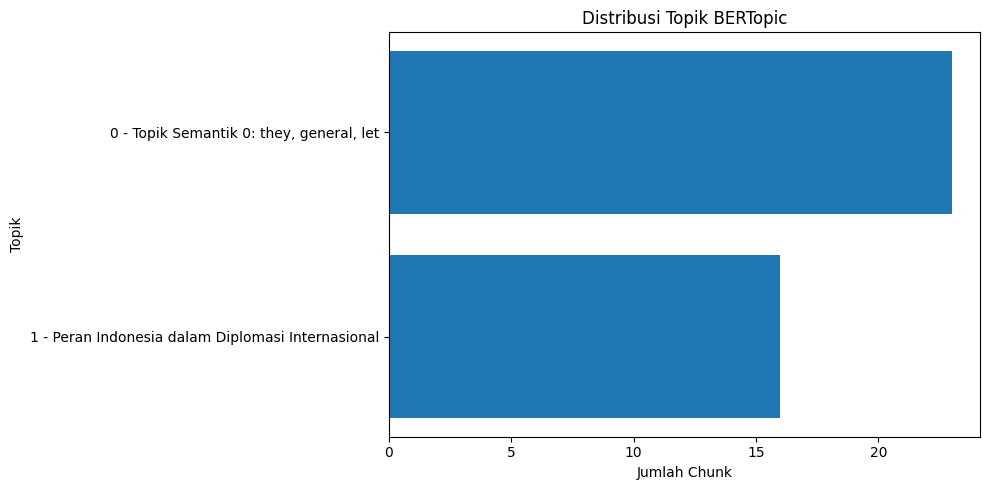

Visualisasi distribusi topik disimpan ke: D:\DATA-KAMIL\MATKUL\SEMESTER-1\DATA-MINING\topic-modeling-prabowo-un-speech\reports\figures\bertopic_topic_distribution.png


In [28]:
# ============================================================
# Visualisasi distribusi topik
# ============================================================

plot_df = topic_distribution_df.sort_values("document_count", ascending=True).copy()
plot_labels = plot_df["bertopic_topic_id"].astype(str) + " - " + plot_df["bertopic_topic_label"].astype(str)

plt.figure(figsize=(10, max(5, 0.5 * len(plot_df))))
plt.barh(plot_labels, plot_df["document_count"])
plt.title("Distribusi Topik BERTopic")
plt.xlabel("Jumlah Chunk")
plt.ylabel("Topik")
plt.tight_layout()

bertopic_dist_fig_path = REPORTS_FIGURES_DIR / "bertopic_topic_distribution.png"
plt.savefig(bertopic_dist_fig_path, dpi=300, bbox_inches="tight")
plt.show()

print("Visualisasi distribusi topik disimpan ke:", bertopic_dist_fig_path)

**Output yang diharapkan:** grafik distribusi topik tampil dan disimpan.  
**Interpretasi:** grafik ini cocok digunakan pada slide presentasi kepada dosen.

In [29]:
# ============================================================
# Visualisasi BERTopic interaktif jika memungkinkan
# ============================================================

try:
    fig_topics = topic_model.visualize_topics(custom_labels=True)
    topics_html_path = REPORTS_FIGURES_DIR / "bertopic_visualize_topics.html"
    fig_topics.write_html(str(topics_html_path))
    print("visualize_topics disimpan ke:", topics_html_path)
except Exception as e:
    print("visualize_topics gagal:", type(e).__name__, str(e))

try:
    fig_barchart = topic_model.visualize_barchart(top_n_topics=10, n_words=10, custom_labels=True)
    barchart_html_path = REPORTS_FIGURES_DIR / "bertopic_topic_barchart.html"
    fig_barchart.write_html(str(barchart_html_path))
    print("visualize_barchart disimpan ke:", barchart_html_path)
except Exception as e:
    print("visualize_barchart gagal:", type(e).__name__, str(e))

visualize_topics gagal: ValueError zero-size array to reduction operation maximum which has no identity
visualize_barchart disimpan ke: D:\DATA-KAMIL\MATKUL\SEMESTER-1\DATA-MINING\topic-modeling-prabowo-un-speech\reports\figures\bertopic_topic_barchart.html


**Output yang diharapkan:** visualisasi HTML tersimpan jika jumlah topik memadai.  
**Interpretasi:** visualisasi HTML berguna untuk eksplorasi, sedangkan PNG distribusi topik lebih stabil untuk laporan.

## 20. Export Hasil ke CSV dan Simpan Model

In [30]:
# ============================================================
# Export hasil ke CSV
# ============================================================

DOCUMENT_TOPICS_OUTPUT = DATA_PROCESSED_DIR / "bertopic_document_topics.csv"
TOPIC_SUMMARY_OUTPUT = DATA_PROCESSED_DIR / "bertopic_topic_summary.csv"
TOPIC_KEYWORDS_OUTPUT = DATA_PROCESSED_DIR / "bertopic_topic_keywords.csv"

document_topics_df.to_csv(DOCUMENT_TOPICS_OUTPUT, index=False, encoding="utf-8-sig")
topic_summary_df.to_csv(TOPIC_SUMMARY_OUTPUT, index=False, encoding="utf-8-sig")
keywords_df.to_csv(TOPIC_KEYWORDS_OUTPUT, index=False, encoding="utf-8-sig")

print("File berhasil diekspor:")
print("1.", DOCUMENT_TOPICS_OUTPUT)
print("2.", TOPIC_SUMMARY_OUTPUT)
print("3.", TOPIC_KEYWORDS_OUTPUT)

File berhasil diekspor:
1. D:\DATA-KAMIL\MATKUL\SEMESTER-1\DATA-MINING\topic-modeling-prabowo-un-speech\data\processed\bertopic_document_topics.csv
2. D:\DATA-KAMIL\MATKUL\SEMESTER-1\DATA-MINING\topic-modeling-prabowo-un-speech\data\processed\bertopic_topic_summary.csv
3. D:\DATA-KAMIL\MATKUL\SEMESTER-1\DATA-MINING\topic-modeling-prabowo-un-speech\data\processed\bertopic_topic_keywords.csv


**Output yang diharapkan:** tiga file CSV berhasil dibuat.  
**Interpretasi:** file ini menjadi artefak utama Tahap 03 untuk laporan dan presentasi.

In [31]:
# ============================================================
# Simpan model BERTopic
# ============================================================

try:
    topic_model.save(
        str(MODELS_DIR),
        serialization="safetensors",
        save_ctfidf=True,
        save_embedding_model=False,
    )
    print("Model BERTopic berhasil disimpan ke:", MODELS_DIR)
except TypeError:
    topic_model.save(str(MODELS_DIR))
    print("Model BERTopic berhasil disimpan dengan metode fallback ke:", MODELS_DIR)
except Exception as e:
    print("Model gagal disimpan:", type(e).__name__, str(e))

2026-06-11 05:11:29,570 - BERTopic - WARNING: You are saving a BERTopic model without explicitly defining an embedding model.If you are using a sentence-transformers model or a HuggingFace model supportedby sentence-transformers, please save the model by using a pointer towards that model.For example, `save_embedding_model='sentence-transformers/all-mpnet-base-v2'`


Model BERTopic berhasil disimpan ke: D:\DATA-KAMIL\MATKUL\SEMESTER-1\DATA-MINING\topic-modeling-prabowo-un-speech\models\bertopic_model


**Output yang diharapkan:** model tersimpan ke `models/bertopic_model/`.  
**Interpretasi:** model yang tersimpan dapat digunakan kembali tanpa training ulang. Jika penyimpanan model gagal, output CSV tetap cukup sebagai artefak utama tugas.

## 21. Interpretasi Akademik Hasil BERTopic

In [32]:
# ============================================================
# Template narasi interpretasi akademik otomatis
# ============================================================

print("Narasi interpretasi awal:")
print("=" * 80)

for _, row in topic_summary_df.iterrows():
    topic_id = row["topic_id"]
    label = row["topic_label"]
    count = row["document_count"]
    pct = row["percentage"]
    keywords = row["keywords"]
    if topic_id == -1:
        print(f"Topic {topic_id} ({label}) mencakup {count} chunk atau {pct}% dari keseluruhan dokumen. Chunk dalam kategori ini tidak memiliki kedekatan semantik yang cukup kuat dengan topik lain, sehingga diperlakukan sebagai outlier.")
    else:
        print(f"Topic {topic_id} diberi label '{label}' karena didominasi oleh kata/frasa kunci seperti: {keywords}. Topik ini mencakup {count} chunk atau {pct}% dari keseluruhan dokumen.")
    print()

Narasi interpretasi awal:
Topic 0 diberi label 'Topik Semantik 0: they, general, let' karena didominasi oleh kata/frasa kunci seperti: they, general, let, path, leaders, general assembly, achieve, humanity, the path, their. Topik ini mencakup 23 chunk atau 58.97% dari keseluruhan dokumen.

Topic 1 diberi label 'Peran Indonesia dalam Diplomasi Internasional' karena didominasi oleh kata/frasa kunci seperti: indonesia, security, oppression, poverty, rice, revolution, poverty and, needs, must also, sense. Topik ini mencakup 16 chunk atau 41.03% dari keseluruhan dokumen.



**Output yang diharapkan:** narasi interpretasi per topik tampil.  
**Interpretasi:** narasi ini dapat digunakan sebagai draft penjelasan presentasi, tetapi tetap perlu disesuaikan dengan isi representative documents dan hasil manual analysis.

### Narasi Akademik Siap Pakai

Berdasarkan hasil BERTopic, chunk pidato berhasil dikelompokkan ke dalam beberapa topik semantik. Setiap topik direpresentasikan oleh kata kunci yang diperoleh melalui c-TF-IDF dan diverifikasi menggunakan representative documents. Topik dengan proporsi terbesar dapat dipahami sebagai tema dominan secara komputasional, sedangkan topik dengan proporsi lebih kecil dapat menggambarkan isu pendukung yang tetap memiliki signifikansi substantif.

Hasil BERTopic tidak dimaksudkan untuk menggantikan manual analysis, melainkan menjadi pendekatan komputasional untuk memperkuat interpretasi. Manual analysis memberikan kedalaman makna melalui open coding, axial coding, dan selective coding, sedangkan BERTopic memberikan dukungan berbasis pola semantik dan clustering dokumen. Integrasi keduanya menghasilkan analisis topik yang lebih kuat karena menggabungkan pendekatan kualitatif dan komputasional.

## 22. Keterbatasan Analisis

1. Data berasal dari **satu pidato**, sehingga variasi tema lebih terbatas dibanding korpus besar.
2. Chunk bukan dokumen independen sepenuhnya karena masih berasal dari konteks pidato yang sama.
3. Parameter BERTopic sensitif terhadap jumlah dokumen kecil.
4. Label topik tetap membutuhkan interpretasi peneliti.
5. Topic `-1` tidak selalu berarti data buruk, tetapi menunjukkan chunk yang tidak cukup dekat dengan cluster tertentu.

## 23. Troubleshooting Error Umum

### `ModuleNotFoundError: No module named 'bertopic'`

```bash
pip install bertopic
```

### `sentence-transformers` belum terinstall

```bash
pip install sentence-transformers
```

### Error download model embedding

Solusi:

1. pastikan koneksi internet aktif,
2. cek proxy atau SSL certificate,
3. jalankan dari jaringan lain,
4. download model secara manual lalu gunakan path lokal:

```python
embedding_model = SentenceTransformer("D:/models/paraphrase-multilingual-MiniLM-L12-v2")
```

### Terlalu banyak topic `-1`

Coba:

1. `min_samples=1`,
2. `min_cluster_size=2`,
3. `topic_model.reduce_outliers(...)`,
4. `UMAP n_neighbors=3` sampai `5`,
5. pastikan chunk tidak terlalu pendek.

### Hasil topic terlalu sedikit

Coba:

1. ubah `nr_topics=None`,
2. gunakan `cluster_selection_method="leaf"`,
3. turunkan `min_cluster_size`,
4. pastikan stopwords tidak terlalu agresif.

### Hasil topic terlalu banyak

Coba:

1. gunakan `nr_topics="auto"`,
2. naikkan `min_cluster_size` menjadi `3` atau `4`,
3. gunakan `cluster_selection_method="eom"`,
4. gabungkan topik secara manual berdasarkan kedekatan makna.

## 24. Alternatif Parameter Eksperimen

In [33]:
# ============================================================
# Alternatif parameter eksperimen
# ============================================================

alternative_configs = {
    "kurangi_outlier": {
        "umap_n_neighbors": 3,
        "hdbscan_min_cluster_size": 2,
        "hdbscan_min_samples": 1,
        "nr_topics": None,
        "catatan": "Cocok jika terlalu banyak topic -1. Risiko: topik bisa lebih banyak."
    },
    "kurangi_jumlah_topik": {
        "umap_n_neighbors": 5,
        "hdbscan_min_cluster_size": 3,
        "hdbscan_min_samples": 1,
        "nr_topics": "auto",
        "catatan": "Cocok jika topik terlalu banyak atau terlalu granular."
    },
    "topik_lebih_granular": {
        "umap_n_neighbors": 3,
        "hdbscan_min_cluster_size": 2,
        "hdbscan_min_samples": 1,
        "cluster_selection_method": "leaf",
        "nr_topics": None,
        "catatan": "Cocok jika hasil topic terlalu sedikit. Risiko: topik kecil bertambah."
    }
}

pd.DataFrame(alternative_configs).T

,umap_n_neighbors,hdbscan_min_cluster_size,hdbscan_min_samples,nr_topics,catatan,cluster_selection_method
kurangi_outlier,3,2,1,None,Cocok jika terlalu banyak topic -1. Risiko: to...,NaN
kurangi_jumlah_topik,5,3,1,auto,Cocok jika topik terlalu banyak atau terlalu g...,NaN
topik_lebih_granular,3,2,1,None,Cocok jika hasil topic terlalu sedikit. Risiko...,leaf


**Output yang diharapkan:** tabel alternatif parameter tampil.  
**Interpretasi:** gunakan alternatif parameter hanya jika hasil utama belum representatif. Untuk laporan akademik, cukup gunakan satu model utama dan jelaskan alasannya.

## 25. Perintah Git Commit

In [34]:
# ============================================================
# Git status
# ============================================================

!git status

On branch main
Your branch is up to date with 'origin/main'.

Changes not staged for commit:
  (use "git add <file>..." to update what will be committed)
  (use "git restore <file>..." to discard changes in working directory)
	modified:   01_data_preparation_text_chunking.ipynb

Untracked files:
  (use "git add <file>..." to include in what will be committed)
	../data/processed/bertopic_document_topics.csv
	../data/processed/bertopic_topic_keywords.csv
	../data/processed/bertopic_topic_summary.csv
	03_bertopic_topic_modeling.ipynb
	../reports/

no changes added to commit (use "git add" and/or "git commit -a")


In [35]:
# ============================================================
# Git add dan commit
# Jalankan setelah output sudah benar.
# ============================================================

!git add notebooks/03_bertopic_topic_modeling.ipynb
!git add data/processed/bertopic_document_topics.csv
!git add data/processed/bertopic_topic_summary.csv
!git add data/processed/bertopic_topic_keywords.csv
!git add reports/figures/
!git add models/bertopic_model/

!git commit -m "Add BERTopic topic modeling analysis"

fatal: pathspec 'notebooks/03_bertopic_topic_modeling.ipynb' did not match any files
fatal: pathspec 'data/processed/bertopic_document_topics.csv' did not match any files
fatal: pathspec 'data/processed/bertopic_topic_summary.csv' did not match any files
fatal: pathspec 'data/processed/bertopic_topic_keywords.csv' did not match any files
fatal: pathspec 'reports/figures/' did not match any files
fatal: pathspec 'models/bertopic_model/' did not match any files


On branch main
Your branch is up to date with 'origin/main'.

Changes not staged for commit:
  (use "git add <file>..." to update what will be committed)
  (use "git restore <file>..." to discard changes in working directory)
	modified:   01_data_preparation_text_chunking.ipynb

Untracked files:
  (use "git add <file>..." to include in what will be committed)
	../data/processed/bertopic_document_topics.csv
	../data/processed/bertopic_topic_keywords.csv
	../data/processed/bertopic_topic_summary.csv
	03_bertopic_topic_modeling.ipynb
	../reports/

no changes added to commit (use "git add" and/or "git commit -a")


In [ ]:
# ============================================================
# Opsional: push ke GitHub
# ============================================================

!git branch

# Jika branch utama adalah main dan sudah siap push:
# !git push origin main

**Output yang diharapkan:** commit berhasil dibuat.  
**Interpretasi:** commit ini menandai selesainya Tahap 03 pada repository GitHub.

## 26. Kesimpulan Tahap 03

Tahap 03 menghasilkan:

1. `data/processed/bertopic_document_topics.csv`
2. `data/processed/bertopic_topic_summary.csv`
3. `data/processed/bertopic_topic_keywords.csv`
4. visualisasi di `reports/figures/`
5. model di `models/bertopic_model/` jika penyimpanan berhasil

Tahap berikutnya yang disarankan adalah **Tahap 04 — Comparative Analysis antara Manual Analysis dan BERTopic**, yaitu membandingkan tema manual coding dengan topic modeling secara sistematis.

## 27. Referensi Singkat

1. Grootendorst, M. (2022). *BERTopic: Neural topic modeling with a class-based TF-IDF procedure*. arXiv:2203.05794.
2. McInnes, L., Healy, J., & Melville, J. (2018). *UMAP: Uniform Manifold Approximation and Projection for Dimension Reduction*.
3. Campello, R. J. G. B., Moulavi, D., & Sander, J. (2013). *Density-Based Clustering Based on Hierarchical Density Estimates*.
4. Sentence Transformers documentation: `paraphrase-multilingual-MiniLM-L12-v2`.
5. BERTopic official documentation.